![](../img/330-banner.png)

# Lecture 9: Classification metrics

UBC, 2025-26

## Imports and LOs

### Imports

In [1]:
import os
import sys

sys.path.append(os.path.join(os.path.abspath(".."), "code"))

import IPython
import matplotlib.pyplot as plt
import mglearn
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from plotting_functions import *
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

import warnings

# Only ignore RuntimeWarnings (like divide by zero)
warnings.filterwarnings('ignore', category=RuntimeWarning)
%matplotlib inline
pd.set_option("display.max_colwidth", 200)

from IPython.display import Image
pd.set_option("display.max_colwidth", 200)
DATA_DIR = "../data/"

In [2]:
# Changing global matplotlib settings for confusion matrix.
plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

### Learning outcomes 

From this lecture, students are expected to be able to:

- Explain why accuracy is not always the best metric in ML.
- Explain components of a confusion matrix. 
- Define precision, recall, and f1-score and use them to evaluate different classifiers. 
- Broadly explain macro-average, weighted average.
- Interpret and use precision-recall curves. 
- Explain average precision score.
- Interpret and use ROC curves and ROC AUC using `scikit-learn`.  
- Identify whether there is class imbalance and whether you need to deal with it.
- Explain and use `class_weight` to deal with data imbalance.
- Assess model performance on specific groups in a dataset. 

<br><br>

### Machine learning workflow 

- Here is a typical workflow of a supervised machine learning systems. 
- So far, we have talked about data splitting, preprocessing, some EDA, model selection with hyperparameter optimization, and interpretation in the context of linear models.
- In the next few lectures, we will talk about evaluation metrics and model selection in terms of evaluation metrics, feature engineering, feature selection, and model transparency and interpretation.  

<!-- ![](img/ml-workflow.png) -->

<img src="../img/ml-workflow.png" height="800" width="800"> 



<br><br><br><br>

## Evaluation metrics for binary classification: Motivation 

### Dataset for demonstration 

- Let's classify fraudulent and non-fraudulent transactions using Kaggle's [Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud) data set.
    - Note, that the credit card fraud detection data set is very large (150mb!) so we've stored it using [GitLFS](https://josh-ops.com/posts/add-files-to-git-lfs/) in a personal repo. You should download the data locally to follow-along, and be sure not to commit large data files to your repository!

In [3]:
# This dataset will be loaded using a URL instead of a CSV file
DATA_URL = "https://github.com/firasm/bits/raw/refs/heads/master/creditcard.csv"

cc_df = pd.read_csv(DATA_URL, encoding="latin-1")
train_df, test_df = train_test_split(cc_df, test_size=0.3, random_state=111)
train_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
64454,51150.0,-3.538816,3.481893,-1.827130,-0.573050,2.644106,-0.340988,2.102135,-2.939006,2.578654,...,0.530978,-0.860677,-0.201810,-1.719747,0.729143,-0.547993,-0.023636,-0.454966,1.00,0
37906,39163.0,-0.363913,0.853399,1.648195,1.118934,0.100882,0.423852,0.472790,-0.972440,0.033833,...,0.687055,-0.094586,0.121531,0.146830,-0.944092,-0.558564,-0.186814,-0.257103,18.49,0
79378,57994.0,1.193021,-0.136714,0.622612,0.780864,-0.823511,-0.706444,-0.206073,-0.016918,0.781531,...,-0.310405,-0.842028,0.085477,0.366005,0.254443,0.290002,-0.036764,0.015039,23.74,0
245686,152859.0,1.604032,-0.808208,-1.594982,0.200475,0.502985,0.832370,-0.034071,0.234040,0.550616,...,0.519029,1.429217,-0.139322,-1.293663,0.037785,0.061206,0.005387,-0.057296,156.52,0
60943,49575.0,-2.669614,-2.734385,0.662450,-0.059077,3.346850,-2.549682,-1.430571,-0.118450,0.469383,...,-0.228329,-0.370643,-0.211544,-0.300837,-1.174590,0.573818,0.388023,0.161782,57.50,0


In [4]:
train_df.shape

(199364, 31)

- Good size dataset 
- For confidentially reasons, it only provides transformed features with PCA, which is a popular dimensionality reduction technique. 

### EDA

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199364 entries, 64454 to 129900
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    199364 non-null  float64
 1   V1      199364 non-null  float64
 2   V2      199364 non-null  float64
 3   V3      199364 non-null  float64
 4   V4      199364 non-null  float64
 5   V5      199364 non-null  float64
 6   V6      199364 non-null  float64
 7   V7      199364 non-null  float64
 8   V8      199364 non-null  float64
 9   V9      199364 non-null  float64
 10  V10     199364 non-null  float64
 11  V11     199364 non-null  float64
 12  V12     199364 non-null  float64
 13  V13     199364 non-null  float64
 14  V14     199364 non-null  float64
 15  V15     199364 non-null  float64
 16  V16     199364 non-null  float64
 17  V17     199364 non-null  float64
 18  V18     199364 non-null  float64
 19  V19     199364 non-null  float64
 20  V20     199364 non-null  float64
 21  V21     199

In [6]:
train_df.describe(include="all")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,...,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000,199364.000000
mean,94888.815669,0.000492,-0.000726,0.000927,0.000630,0.000036,0.000011,-0.001286,-0.002889,-0.000891,...,0.001205,0.000155,-0.000198,0.000113,0.000235,0.000312,-0.000366,0.000227,88.164679,0.001700
std,47491.435489,1.959870,1.645519,1.505335,1.413958,1.361718,1.327188,1.210001,1.214852,1.096927,...,0.748510,0.726634,0.628139,0.605060,0.520857,0.481960,0.401541,0.333139,238.925768,0.041201
min,0.000000,-56.407510,-72.715728,-31.813586,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.320155,...,-34.830382,-8.887017,-44.807735,-2.824849,-10.295397,-2.241620,-22.565679,-11.710896,0.000000,0.000000
25%,54240.000000,-0.918124,-0.600193,-0.892476,-0.847178,-0.691241,-0.768512,-0.553979,-0.209746,-0.642965,...,-0.227836,-0.541795,-0.162330,-0.354604,-0.317761,-0.326730,-0.070929,-0.052819,5.640000,0.000000
50%,84772.500000,0.018854,0.065463,0.179080,-0.019531,-0.056703,-0.275290,0.040497,0.022039,-0.052607,...,-0.029146,0.007666,-0.011678,0.041031,0.016587,-0.052790,0.001239,0.011234,22.000000,0.000000
75%,139349.250000,1.315630,0.803617,1.028023,0.744201,0.610407,0.399827,0.570449,0.327408,0.597326,...,0.186899,0.529210,0.146809,0.439209,0.351366,0.242169,0.090453,0.078052,77.150000,0.000000
max,172792.000000,2.451888,22.057729,9.382558,16.491217,34.801666,23.917837,44.054461,19.587773,15.594995,...,27.202839,10.503090,22.083545,4.022866,6.070850,3.517346,12.152401,33.847808,11898.090000,1.000000


- We do not have categorical features. All features are numeric. 
- We have to be careful about the `Time` and `Amount` features. 
- We could scale `Amount`. 
- Do we want to scale time?
    - In this lecture, we'll just drop the Time feature. 
    - We'll learn about time series briefly later in the course. 

Let's separate `X` and `y` for train and test splits.

In [7]:
X_train_big, y_train_big = train_df.drop(columns=["Class", "Time"]), train_df["Class"]
X_test, y_test = test_df.drop(columns=["Class", "Time"]), test_df["Class"]

- It's easier to demonstrate evaluation metrics using an explicit validation set instead of using cross-validation. 
- So let's create a validation set. 
- Our data is large enough so it shouldn't be a problem. 


In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_big, y_train_big, test_size=0.3, random_state=123
)

### Baseline

In [9]:
dummy = DummyClassifier()
pd.DataFrame(cross_validate(dummy, X_train, y_train, return_train_score=True)).mean()

fit_time       0.005742
score_time     0.000432
test_score     0.998302
train_score    0.998302
dtype: float64

### Observations 

- `DummyClassifier` is getting 0.998 cross-validation accuracy!! 
- Should we be happy with this accuracy and deploy this `DummyClassifier` model for fraud detection? 

What's the class distribution? 

In [10]:
train_df["Class"].value_counts(normalize=True)

Class
0    0.9983
1    0.0017
Name: proportion, dtype: float64

- We have class imbalance. 
- We have MANY non-fraud transactions and only a handful of fraud transactions. 
- So in the training set, `most_frequent` strategy is labeling 199,025 (99.83%) instances correctly and only 339 (0.17%) instances incorrectly. 
- Is this what we want? 
- The "fraud" class is the important class that we want to spot. 

Let's scale the features and try `LogisticRegression`.   

In [11]:
pipe = make_pipeline(StandardScaler(), LogisticRegression())
pd.DataFrame(cross_validate(pipe, X_train, y_train, return_train_score=True)).mean()

fit_time       0.045865
score_time     0.001679
test_score     0.999183
train_score    0.999221
dtype: float64

- We are getting a slightly better score with logistic regression.  
- What score should be considered an acceptable score here? 
- Are we actually spotting any "fraud" transactions? 

- `.score` by default returns accuracy which is 
$$\frac{\text{correct predictions}}{\text{total examples}}$$
- Is accuracy a good metric here? 
- Is there anything more informative than accuracy that we can use here? 

Let's dig a little deeper.

<br><br><br><br>

## Confusion matrix and related metrics

One way to get a better understanding of the errors is by looking at 
- false positives (type I errors), where the model incorrectly spots examples as fraud
- false negatives (type II errors), where it's missing to spot fraud examples 

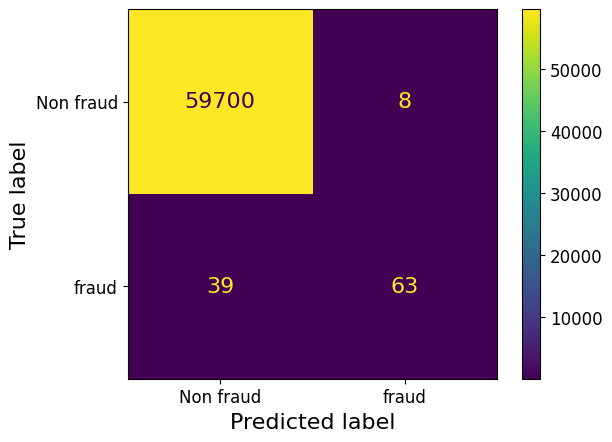

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay  # Recommended method in sklearn 1.0

pipe.fit(X_train, y_train)
cm = ConfusionMatrixDisplay.from_estimator(
    pipe, X_valid, y_valid, values_format="d", display_labels=["Non fraud", "fraud"]
)

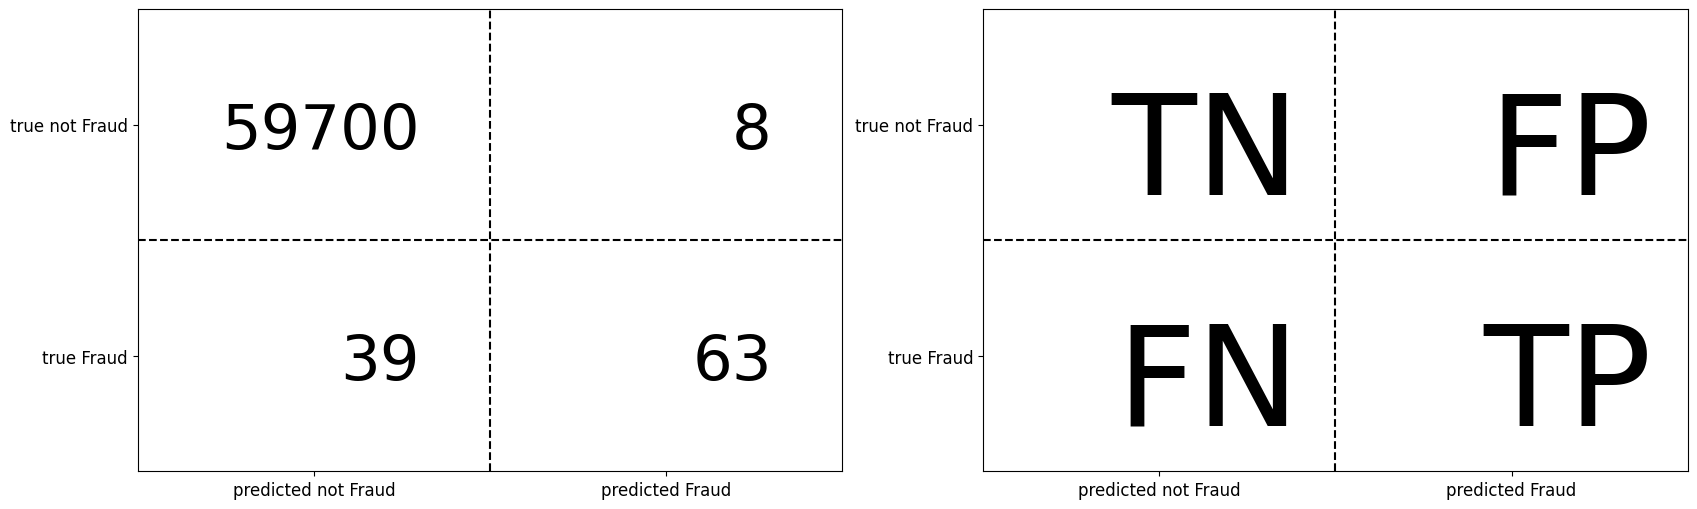

In [13]:
from sklearn.metrics import confusion_matrix

predictions = pipe.predict(X_valid)
TN, FP, FN, TP = confusion_matrix(y_valid, predictions).ravel()
plot_confusion_matrix_example(TN, FP, FN, TP)

- Perfect prediction has all values down the diagonal
- Off diagonal entries can often tell us about what is being mis-predicted

### What is "positive" and "negative"?

- Two kinds of binary classification problems 
    - Distinguishing between two classes
    - Spotting a class (spot fraud transaction, spot spam, spot disease)
- In case of spotting problems, the thing that we are interested in spotting is considered "positive". 
- Above we wanted to spot fraudulent transactions and so they are "positive". 

You can get a numpy array of confusion matrix as follows: 

In [14]:
from sklearn.metrics import confusion_matrix

predictions = pipe.predict(X_valid)
TN, FP, FN, TP = confusion_matrix(y_valid, predictions).ravel()
print("Confusion matrix for fraud data set")
print(cm.confusion_matrix)

Confusion matrix for fraud data set
[[59700     8]
 [   39    63]]


### Confusion matrix with cross-validation 

- You can also calculate confusion matrix with cross-validation using the `cross_val_predict` method.  
- But then you cannot plot it in a nice format. 

In [15]:
from sklearn.model_selection import cross_val_predict

confusion_matrix(y_train, cross_val_predict(pipe, X_train, y_train))

array([[139297,     20],
       [    94,    143]])

<br><br>

### Precision, recall, f1 score 

- We have been using `.score` to assess our models, which returns accuracy by default.
  
- Accuracy can be misleading when we have class imbalance.

- We need additional metrics to assess our models.
- We'll discuss three commonly used metrics which are derived from the confusion matrix: 
    - Recall
    - Precision
    - F1-score
      
- Note that these metrics evaluate model performance but do not fix imbalance. 

- Later, we'll discuss methods to address class imbalance. 

<br><br>

### Precision and recall: toy example

- The confusion matrix helps us track four cases:

    - TP (True Positives) $\rightarrow$ Fraud correctly flagged as fraud
    
    - FP (False Positives) $\rightarrow$ Non-fraud incorrectly flagged as fraud
    
    - TN (True Negatives) $\rightarrow$ Non-fraud correctly flagged as non-fraud
    
    - FN (False Negatives) $\rightarrow$ Fraud missed (predicted as non-fraud)

- Imagine that your model has identified everything outside the circle as non-fraud and everything inside the circle as fraud. 

![](../img/precision-recall.png)

![](../img/fraud-precision-recall.png)

- **Precision**: Of all predicted fraud cases, how many are actually fraud?
  - $\text{Precision} = \frac{TP}{TP + FP}$
    
  - Hight precision $\rightarrow$ few false alarms 

- **Recall**: Of all actual fraud cases, how many did we successfully catch?  
  - $\text{Recall} = \frac{TP}{TP + FN}$
  
  - High recall $\rightarrow$ we miss fewer fraud cases

- The picture above shows the tradeoff between precision and recall.

  - Left figure $\rightarrow$ High precision, low recall (we're very careful, but miss many frauds).
    
  - Right figure $\rightarrow$ Higher recall, lower precision (we catch more frauds, but raise more false alarms).

- In fraud detection, predicting correctly matters more than just overall accuracy.

Let's look at how precision and recall apply to our dataset.

In [16]:
from sklearn.metrics import confusion_matrix

pipe_lr = make_pipeline(StandardScaler(), LogisticRegression())
pipe_lr.fit(X_train, y_train)
predictions = pipe_lr.predict(X_valid)
TN, FP, FN, TP = confusion_matrix(y_valid, predictions).ravel()
print(cm.confusion_matrix)

[[59700     8]
 [   39    63]]


First, let's see how these metrics are defined from the confusion matrix.

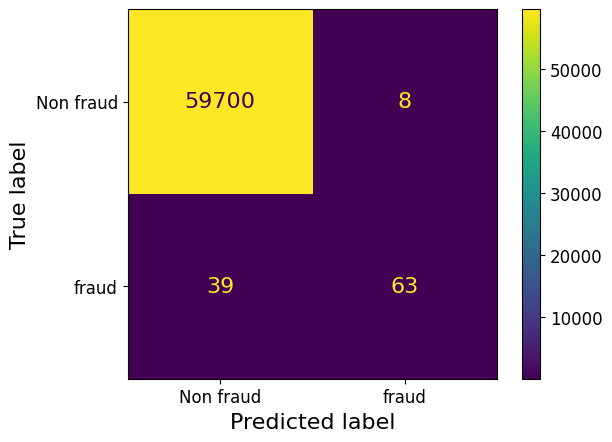

In [17]:
cm = ConfusionMatrixDisplay.from_estimator(
    pipe, X_valid, y_valid, values_format="d", display_labels=["Non fraud", "fraud"]
);

**Precision** = When the model says positive, how often is it correct?

$$ precision = \frac{TP}{TP+FP}$$

In [18]:
print("TP = %0.4f, FP = %0.4f" % (TP, FP))
precision = TP / (TP + FP)
print("Precision: %0.4f" % (precision))

TP = 63.0000, FP = 8.0000
Precision: 0.8873


<br><br>

**Recall** = Of all actual positive cases, how many did the model correctly identify?  

$$ recall = \frac{TP}{TP+FN} = \frac{TP}{\#positives} $$

- Also known as sensitivity, coverage, true positive rate (TPR)

In [19]:
print("TP = %0.4f, FN = %0.4f" % (TP, FN))
recall = TP / (TP + FN)
print("Recall: %0.4f" % (recall))

TP = 63.0000, FN = 39.0000
Recall: 0.6176


Precision and recall sometimes trade off against each other. **F1-score** combines them into a single number. It's defined as the harmonic mean of precision and recall:  

$$ f1 = 2 \times \frac{ precision \times recall}{precision + recall}$$

Useful when

- We want a single metric for model comparison
- Especially in hyperparameter optimization with imbalanced data  


In [20]:
print("precision: %0.4f" % (precision))
print("recall: %0.4f" % (recall))
f1_score = (2 * precision * recall) / (precision + recall)
print("f1: %0.4f" % (f1_score))

precision: 0.8873
recall: 0.6176
f1: 0.7283


Let's look at all metrics at once on our dataset.

In [21]:
## Calculate evaluation metrics by ourselves
data = {
    "calculation": [],
    "accuracy": [],
    "error": [],
    "precision": [],
    "recall": [],
    "f1 score": [],
}
data["calculation"].append("manual")
data["accuracy"].append((TP + TN) / (TN + FP + FN + TP))
data["error"].append((FP + FN) / (TN + FP + FN + TP))
data["precision"].append(precision)  # TP / (TP + FP)
data["recall"].append(recall)  # TP / (TP + FN)
data["f1 score"].append(f1_score)  # (2 * precision * recall) / (precision + recall)
df = pd.DataFrame(data)
df

,calculation,accuracy,error,precision,recall,f1 score
0,manual,0.999214,0.000786,0.887324,0.617647,0.728324


<br><br>

`scikit-learn` has functions for [these metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics). Now, let's compute them one by one in sklearn to confirm our formulas.

In [22]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

data["accuracy"].append(accuracy_score(y_valid, pipe_lr.predict(X_valid)))
data["error"].append(1 - accuracy_score(y_valid, pipe_lr.predict(X_valid)))
data["precision"].append(
    precision_score(y_valid, pipe_lr.predict(X_valid), zero_division=1)
)
data["recall"].append(recall_score(y_valid, pipe_lr.predict(X_valid)))
data["f1 score"].append(f1_score(y_valid, pipe_lr.predict(X_valid)))
data["calculation"].append("sklearn")
df = pd.DataFrame(data)
df.set_index(["calculation"])

,accuracy,error,precision,recall,f1 score
calculation,,,,,
manual,0.999214,0.000786,0.887324,0.617647,0.728324
sklearn,0.999214,0.000786,0.887324,0.617647,0.728324


The scores match! 

<br><br>

Finally, sklearn has a convenient `classification_report` that puts everything together in one place. This is what you’ll often use in practice.

In [23]:
pipe_lr.classes_

array([0, 1])

In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid, pipe_lr.predict(X_valid), target_names=["non-fraud", "fraud"]
    )
)

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     59708
       fraud       0.89      0.62      0.73       102

    accuracy                           1.00     59810
   macro avg       0.94      0.81      0.86     59810
weighted avg       1.00      1.00      1.00     59810



```{note}
Check out [Appendix A (Lecture 09)](AppendixA.ipynb) for an explanation and a toy example of macro and weighted averages.
```

<br><br>

- We can pass different evaluation metrics with `scoring` argument of `cross_validate`.

In [25]:
scoring = [
    "accuracy",
    "f1",
    "recall",
    "precision",
]  # scoring can be a string, a list, or a dictionary
pipe = make_pipeline(StandardScaler(), LogisticRegression())
scores = cross_validate(
    pipe, X_train_big, y_train_big, return_train_score=True, scoring=scoring
)
pd.DataFrame(scores)

,fit_time,score_time,test_accuracy,train_accuracy,test_f1,train_f1,test_recall,train_recall,test_precision,train_precision
0,0.075599,0.007324,0.999122,0.999335,0.700855,0.772532,0.602941,0.664207,0.836735,0.923077
1,0.073740,0.006930,0.999223,0.999317,0.735043,0.765591,0.632353,0.656827,0.877551,0.917526
2,0.078742,0.006745,0.999298,0.999210,0.754386,0.724891,0.632353,0.612546,0.934783,0.887701
3,0.072787,0.006491,0.999172,0.999254,0.697248,0.742981,0.558824,0.634686,0.926829,0.895833
4,0.066616,0.006884,0.999147,0.999185,0.696429,0.716157,0.582090,0.602941,0.866667,0.881720


- You can also create [your own scoring function](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) and pass it to `cross_validate`. 

```{note}
Check out [Appendix A (Lecture 09)](AppendixA.ipynb) for an example of evaluation metrics in multi-class classification.  
```

<br><br>

### Interim summary 

- Accuracy can be misleading with class imbalance.
- Confusion matrix helps break down model errors.

- Metrics derived from the confusion matrix:

    - Precision
    - Recall
    - F1-score

- Choice of the positive class (e.g., fraud) matters:
    - Flipping positive/negative changes TP, FP, TN, FN, which changes precision, recall, and F1

- There is lots of new terminology. we have made a cheatsheet of key formulas: 

<!-- <img src='./img/evaluation-metrics.png' width="1000" height="1000" /> -->

![](../img/evaluation-metrics.png)

<br><br>

## ❓❓ Questions for you

### iClicker Exercise 9.1 

**Select all of the following statements which are TRUE.**

- (A) In medical diagnosis, false positives are more damaging than false negatives (assume "positive" means the person has a disease, "negative" means they don't).
- (B) In spam classification, false positives are more damaging than false negatives (assume "positive" means the email is spam, "negative" means they it's not).
- (C) If method A gets a higher accuracy than method B, that means its precision is also higher.
- (D) If method A gets a higher accuracy than method B, that means its recall is also higher.

Method A - higher accuracy but lower precision

| Negative | Positive
| -------- |:-------------:|
| 90      | 5|
| 5      | 0|

Method B - lower accuracy but higher precision

| Negative | Positive
| -------- |:-------------:|
| 80      | 15|
| 0      | 5|




<br><br><br><br>

## Precision-recall curve

- Confusion matrix provides a detailed break down of the errors made by the model. 
- But when creating a confusion matrix, we are using "hard" predictions. 
- Most classifiers in `scikit-learn` provide `predict_proba` method (or `decision_function`) which provides degree of certainty about predictions by the classifier. 
- Can we explore the degree of uncertainty to understand and improve the model performance? 

Let's revisit the classification report on our fraud detection example. 

In [26]:
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression())
pipe_lr.fit(X_train, y_train);

In [27]:
y_pred = pipe_lr.predict(X_valid)
print(classification_report(y_valid, y_pred, target_names=["non-fraud", "fraud"]))

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     59708
       fraud       0.89      0.62      0.73       102

    accuracy                           1.00     59810
   macro avg       0.94      0.81      0.86     59810
weighted avg       1.00      1.00      1.00     59810



By default, predictions use the threshold of 0.5. If `predict_proba` > 0.5, predict "fraud" else predict "non-fraud".

In [28]:
y_pred = pipe_lr.predict_proba(X_valid)[:, 1] > 0.50
print(classification_report(y_valid, y_pred, target_names=["non-fraud", "fraud"]))

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     59708
       fraud       0.89      0.62      0.73       102

    accuracy                           1.00     59810
   macro avg       0.94      0.81      0.86     59810
weighted avg       1.00      1.00      1.00     59810



- Suppose for your business it is more costly to miss fraudulent transactions and suppose you want to achieve a recall of at least 75% for the "fraud" class. 
- One way to do this is by changing the threshold of `predict_proba`.
    - `predict` returns 1 when `predict_proba`'s probabilities are above 0.5 for the "fraud" class.

**Key idea: what if we threshold the probability at a smaller value so that we identify more examples as "fraud" examples?** 

Let's lower the threshold to 0.1. In other words, predict the examples as "fraud" if `predict_proba` > 0.1.  

In [29]:
y_pred_lower_threshold = pipe_lr.predict_proba(X_valid)[:, 1] > 0.1

In [30]:
print(classification_report(y_valid, y_pred_lower_threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59708
           1       0.77      0.75      0.76       102

    accuracy                           1.00     59810
   macro avg       0.88      0.88      0.88     59810
weighted avg       1.00      1.00      1.00     59810



### Operating point 

- Now our recall for "fraud" class is >= 0.75. 
- Setting a requirement on a classifier (e.g., recall of >= 0.75) is called setting the **operating point**. 
- It's usually driven by business goals and is useful to make performance guarantees to customers. 

### Precision/Recall tradeoff 

- But there is a trade-off between precision and recall. 
- If you identify more things as "fraud", recall is going to increase but there are likely to be more false positives. 

Let's sweep through different thresholds. 

In [31]:
thresholds = np.arange(0.0, 1.0, 0.1)
thresholds

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

You need to install `panel` package in order to run the code below locally. See the documentation [here](https://pyviz-dev.github.io/panel/getting_started/installation.html#jupyterlab-and-classic-notebook). 

```conda install -c pyviz panel```

In [32]:
import panel as pn
from panel import widgets
from panel.interact import interact

pn.extension()

def f(threshold):
    preds = pipe_lr.predict_proba(X_valid)[:, 1] > threshold
    precision = np.round(precision_score(y_valid, preds), 4)
    recall = np.round(recall_score(y_valid, preds), 4)
    d = {'threshold':np.round(threshold, 4), 'Precision': precision, 'recall': recall}
    return (d)

interact(f, threshold=widgets.FloatSlider(start=0.0, end=0.99, step=0.05, value=0.5)).embed(max_opts=20)

### Decreasing the threshold

- Decreasing the threshold means a lower bar for predicting fraud. 
    - You are willing to risk more false positives in exchange of more true positives. 
    - Recall would either stay the same or go up and precision is likely to go down
    - Occasionally, precision may increase if all the new examples after decreasing the threshold are TPs. 

### Increasing the threshold

- Increasing the threshold means a higher bar for predicting fraud. 
    - Recall would go down or stay the same but precision is likely to go up 
    - Occasionally, precision may go down if TP decrease but FP do not decrease.

### Precision-recall curve

Often, when developing a model, it's not always clear what the operating point will be and to understand the model better, it's informative to look at all possible thresholds and corresponding trade-offs of precision and recall in a plot.  


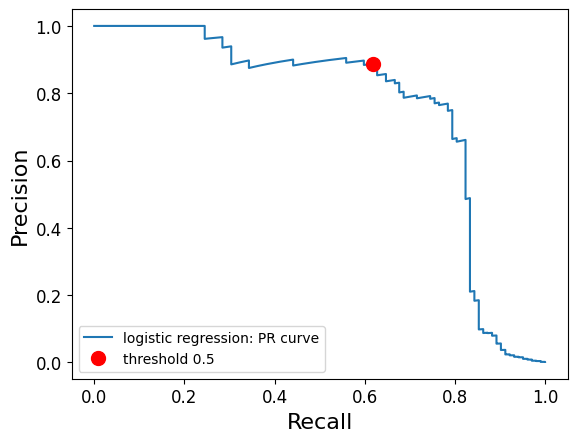

In [33]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_valid, pipe_lr.predict_proba(X_valid)[:, 1]
)
plt.plot(recall, precision, label="logistic regression: PR curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot(
    recall_score(y_valid, pipe_lr.predict(X_valid)),
    precision_score(y_valid, pipe_lr.predict(X_valid)),    
    "or",
    markersize=10,
    label="threshold 0.5",
)
plt.legend(loc="best", fontsize=10);

- Each point in the curve corresponds to a possible threshold of the `predict_proba` output. 
- We can achieve a recall of 0.8 at a precision of 0.4. 
- The red dot marks the point corresponding to the threshold 0.5.
- The top-right would be a perfect classifier (precision = recall = 1).

- The threshold is not shown here, but it's going from 1 (upper-left) to 0 (lower right).
- At a threshold of 0 (lower right), we are classifying everything  as "fraud". So there are many false positives. 
- Increasing the threshold increases the precision but at the expense of lowering the recall. 
- At the extreme left, where the threshold is 1, we get into the situation where all the examples classified as "fraud" are actually "fraud"; we have no false positives. 
- Here we have a high precision but lower recall. 
- Usually the goal is to keep recall high as precision goes up. 

### AP score 

- Often it's useful to have one number summarizing the PR plot (e.g., in hyperparameter optimization)
- One way to do this is by computing the area under the PR curve. 
- This is called **average precision** (AP score)
- AP score has a value between 0 (worst) and 1 (best). 

In [34]:
from sklearn.metrics import average_precision_score

ap_lr = average_precision_score(y_valid, pipe_lr.predict_proba(X_valid)[:, 1])
print("Average precision of logistic regression: {:.3f}".format(ap_lr))

Average precision of logistic regression: 0.757


You can also use the following handy function of `sklearn` to get the PR curve and the corresponding AP score. 

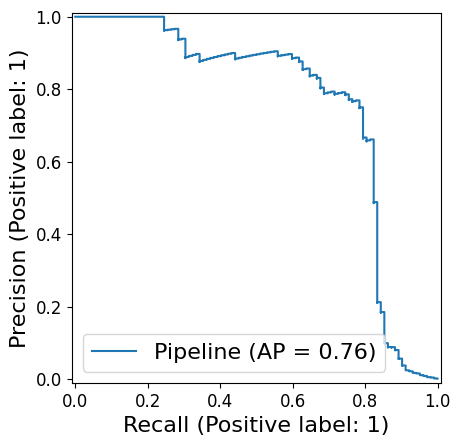

In [35]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(pipe_lr, X_valid, y_valid);

### AP vs. F1-score

It is very important to note this distinction:

- F1 score is for a given threshold and measures the quality of `predict`.
- AP score is a summary across thresholds and measures the quality of `predict_proba`.


```{important}
Remember to pick the desired threshold based on the results on the validation set and **not** on the test set.
```

### A few comments on PR curve

- Different classifiers might work well in different parts of the curve, i.e., at different operating points.   
- We can compare PR curves of different classifiers to understand these differences. 
- Let's create PR curves for SVC and Logistic Regression. 

In [36]:
pipe_svc = make_pipeline(StandardScaler(), SVC())

pipe_svc.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [37]:
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipe_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

How to get precision and recall for different thresholds? 
- Use the function `precision_recall_curve`

In [38]:
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(
    y_valid, pipe_lr.predict_proba(X_valid)[:, 1]
)

### (Optional) Some more details

- How are the thresholds and the precision and recall at the default threshold are calculated? 

How many thresholds? 
- It uses `n_thresholds` where `n_thresholds` is the number of unique `predict_proba` scores in our dataset. 

In [39]:
len(np.unique(pipe_lr.predict_proba(X_valid)[:, 1]))

59049

- For each threshold, precision and recall are calculated.  
- The last precision and recall values are 1. and 0. respectively and do not have a corresponding threshold. 

In [40]:
thresholds_lr.shape, precision_lr.shape, recall_lr.shape

((59049,), (59050,), (59050,))

In [41]:
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(
    y_valid, pipe_lr.predict_proba(X_valid)[:, 1]
)
precision_svc, recall_svc, thresholds_svc = precision_recall_curve(
    y_valid, pipe_svc.decision_function(X_valid)
)

For logistic regression, what's the index of the threshold that is closest to the default threshold of 0.5? 
- We are subtracting 0.5 from the thresholds so that 
    - the numbers close to 0 become -0.5
    - the numbers close to 1 become 0.5    
    - the numbers close to 0.5 become 0
- After this transformation, we are interested in the threshold index where the number is close to 0. So we take  absolute values and argmin.       

In [42]:
close_default_lr = np.argmin(np.abs(thresholds_lr - 0.5))
close_zero_svm = np.argmin(np.abs(thresholds_svc))

SVC doesn't have `predict_proba`. Instead it has something called `decision_function`. The index of the threshold that is closest to 0 of decision function is the default threshold in SVC. 

### PR curves for logistic regression and SVC

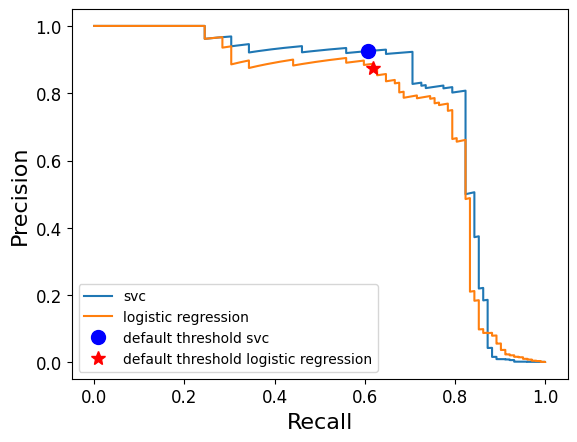

In [43]:
plt.plot(recall_svc, precision_svc, label="svc")
plt.plot(recall_lr, precision_lr, label="logistic regression")
plt.plot(
    recall_svc[close_zero_svm],
    precision_svc[close_zero_svm],    
    "o",
    markersize=10,
    label="default threshold svc",
    c="b",
)
plt.plot(
    recall_lr[close_default_lr],
    precision_lr[close_default_lr],    
    "*",
    markersize=10,
    label="default threshold logistic regression",
    c="r",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="best", fontsize=10);

In [44]:
svc_preds = pipe_svc.predict(X_valid)
lr_preds = pipe_lr.predict(X_valid)

In [45]:
print("f1_score of logistic regression: {:.3f}".format(f1_score(y_valid, lr_preds)))
print("f1_score of svc: {:.3f}".format(f1_score(y_valid, svc_preds)))

f1_score of logistic regression: 0.728
f1_score of svc: 0.726


In [46]:
ap_lr = average_precision_score(y_valid, pipe_lr.predict_proba(X_valid)[:, 1])
ap_svc = average_precision_score(y_valid, pipe_svc.decision_function(X_valid))

In [47]:
print("Average precision of logistic regression: {:.3f}".format(ap_lr))
print("Average precision of SVC: {:.3f}".format(ap_svc))

Average precision of logistic regression: 0.757
Average precision of SVC: 0.790


- Comparing the precision-recall curves provide us a detail insight compared to f1 score.
- For example, F1 scores for SVC and logistic regressions are pretty similar. In fact, f1 score of logistic regression is a tiny bit better. 
- But when we look at the PR curve, we see that SVC is doing better than logistic regression for most of the other thresholds. 

<br><br><br><br>

## Receiver Operating Characteristic (ROC) curve 

- Another commonly used tool to analyze the behavior of classifiers at different thresholds.  
- Similar to PR curve, it considers all possible thresholds for a given classifier given by `predict_proba` but instead of precision and recall it plots false positive rate (FPR) and true positive rate (TPR or recall).
$$ TPR = \frac{TP}{TP + FN}$$

$$ FPR  = \frac{FP}{FP + TN}$$

- TPR $\rightarrow$ Fraction of true positives out of all positive examples. 
- FPR $\rightarrow$ Fraction of false positives out of all negative examples. 


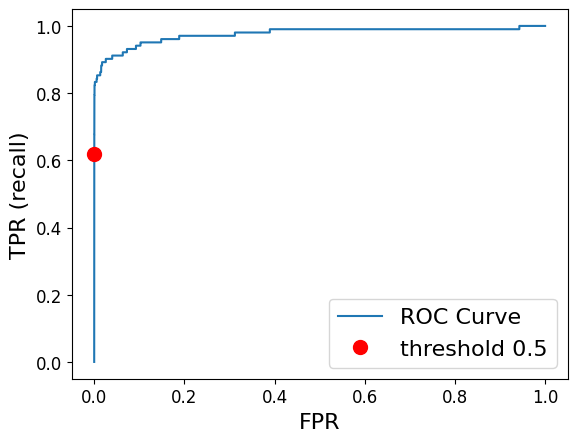

In [48]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_valid, pipe_lr.predict_proba(X_valid)[:, 1])
plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR (recall)")

default_threshold = np.argmin(np.abs(thresholds - 0.5))

plt.plot(
    fpr[default_threshold],
    tpr[default_threshold],
    "or",
    markersize=10,
    label="threshold 0.5",
)
plt.legend(loc="best");

- Different points on the ROC curve represent different classification thresholds. The curve starts at (0,0) and ends at (1, 1).
    - (0, 0) represents the threshold that classifies everything as the negative class
    - (1, 1) represents the threshold that classifies everything as the positive class 
- The ideal curve is close to the top left
    - Ideally, you want a classifier with high recall while keeping low false positive rate.  
- The red dot corresponds to the threshold of 0.5, which is used by predict.
- We see that compared to the default threshold, we can achieve a better recall of around 0.8 without increasing FPR. 

Let's compare ROC curve of different classifiers. 

In [49]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_valid, pipe_lr.predict_proba(X_valid)[:, 1])

fpr_svc, tpr_svc, thresholds_svc = roc_curve(
    y_valid, pipe_svc.decision_function(X_valid)
)

In [50]:
close_default_lr = np.argmin(np.abs(thresholds_lr - 0.5))
close_zero_svm = np.argmin(np.abs(thresholds_svc))

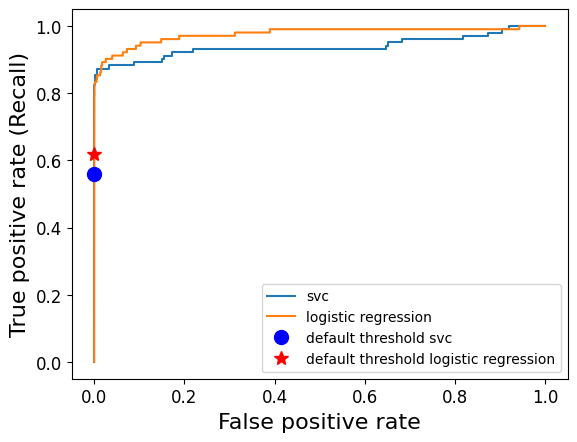

In [51]:
plt.plot(fpr_svc, tpr_svc, label="svc")
plt.plot(fpr_lr, tpr_lr, label="logistic regression")
plt.plot(
    fpr_svc[close_zero_svm],
    tpr_svc[close_zero_svm],
    "o",
    markersize=10,
    label="default threshold svc",
    c="b",
)
plt.plot(
    fpr_lr[close_default_lr],
    tpr_lr[close_default_lr],
    "*",
    markersize=10,
    label="default threshold logistic regression",
    c="r",
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate (Recall)")
plt.legend(loc="best", fontsize=10);

### Area under the curve (AUC)

- AUC provides a single meaningful number for the model performance. 

In [52]:
from sklearn.metrics import roc_auc_score

roc_lr = roc_auc_score(y_valid, pipe_lr.predict_proba(X_valid)[:, 1])
roc_svc = roc_auc_score(y_valid, pipe_svc.decision_function(X_valid))
print("AUC for LR: {:.3f}".format(roc_lr))
print("AUC for SVC: {:.3f}".format(roc_svc))

AUC for LR: 0.976
AUC for SVC: 0.938


- AUC of 0.5 means random chance. 
- AUC can be interpreted as evaluating the **ranking** of positive examples.
- What's the probability that a randomly picked positive point has a higher score according to the classifier than a randomly picked point from the negative class. 
- AUC of 1.0 means all positive points have a higher score than all negative points. 

```{important}
For classification problems with imbalanced classes, using AP score or AUC is often much more meaningful than using accuracy. 
```

Similar to `PrecisionRecallCurveDisplay`, there is a `RocCurveDisplay` function in sklearn. 

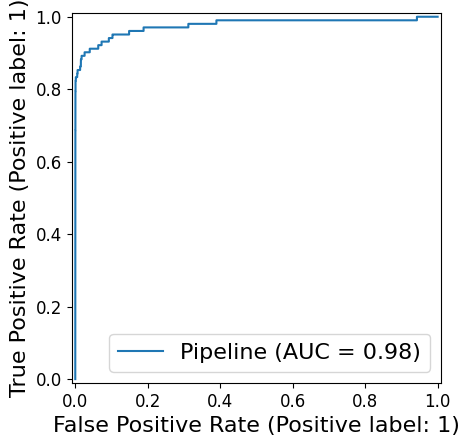

In [53]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(pipe_lr, X_valid, y_valid);

### Let's look at all the scores at once

In [54]:
scoring = ["accuracy", "f1", "recall", "precision", "roc_auc", "average_precision"]
pipe = make_pipeline(StandardScaler(), LogisticRegression())
scores = cross_validate(pipe, X_train_big, y_train_big, scoring=scoring)
pd.DataFrame(scores).mean()

fit_time                  0.069795
score_time                0.014967
test_accuracy             0.999192
test_f1                   0.716792
test_recall               0.601712
test_precision            0.888513
test_roc_auc              0.967907
test_average_precision    0.743135
dtype: float64

```{seealso}
Check out [these visualization](https://github.com/dariyasydykova/open_projects/tree/master/ROC_animation) on ROC and AUC.  
```

```{seealso}
Check out how to plot ROC with cross-validation [here](https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html).
```

## ❓❓ Questions for you

### iClicker Exercise 9.2 

**Select all of the following statements which are TRUE.**

- (A) If we increase the classification threshold, both true and false positives are likely to decrease.
- (B) If we increase the classification threshold, both true and false negatives are likely to decrease.
- (C) Lowering the classification threshold generally increases the model’s recall.  
- (D) Raising the classification threshold can improve the precision of the model if it effectively reduces the number of false positives without significantly affecting true positives.


<br><br><br><br>

## Dealing with class imbalance [[video](https://www.youtube.com/watch?v=jHaKRCFb6Qw)]

### Class imbalance in training sets

- This typically refers to having many more examples of one class than another in one's training set.
- Real world data is often imbalanced. 
    - Our Credit Card Fraud dataset is imbalanced.
    - Ad clicking data is usually drastically imbalanced. (Only around ~0.01% ads are clicked.)
    - Spam classification datasets are also usually imbalanced.

### Addressing class imbalance
A very important question to ask yourself: "Why do I have a class imbalance?"

- Is it because one class is much more rare than the other?
    - If it's just because one is more rare than the other, you need to ask whether you care about one type of error more than the other.    
- Is it because of my data collection methods?
    - If it's the data collection, then that means _your test and training data come from different distributions_!
  
In some cases, it may be fine to just ignore the class imbalance.

### Which type of error is more important? 

- False positives (FPs) and false negatives (FNs) have quite different real-world consequences. 
- In PR curve and ROC curve, we saw how changing the prediction threshold can change FPs and FNs. 
- We can then pick the threshold that's appropriate for our problem. 
- Example: if we want high recall, we may use a lower threshold (e.g., a threshold of 0.1). We'll then catch more fraudulent transactions. 

In [55]:
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression())
pipe_lr.fit(X_train, y_train)
y_pred = pipe_lr.predict(X_valid)
print(classification_report(y_valid, y_pred, target_names=["non-fraud", "fraud"]))

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     59708
       fraud       0.89      0.62      0.73       102

    accuracy                           1.00     59810
   macro avg       0.94      0.81      0.86     59810
weighted avg       1.00      1.00      1.00     59810



In [56]:
y_pred = pipe_lr.predict_proba(X_valid)[:, 1] > 0.10
print(classification_report(y_valid, y_pred, target_names=["non-fraud", "fraud"]))

              precision    recall  f1-score   support

   non-fraud       1.00      1.00      1.00     59708
       fraud       0.77      0.75      0.76       102

    accuracy                           1.00     59810
   macro avg       0.88      0.88      0.88     59810
weighted avg       1.00      1.00      1.00     59810



### Handling imbalance

Can we change the model itself rather than changing the threshold so that it takes into account the errors that are important to us?

There are two common approaches for this: 
- **Changing the data (optional)** (not covered in this course)
   - Undersampling
   - Oversampling 
       - Random oversampling
       - SMOTE 
- **Changing the training procedure** 
    - `class_weight`

### Changing the training procedure 

- All `sklearn` classifiers have a parameter called `class_weight`.
- This allows you to specify that one class is more important than another.
- For example, maybe a false negative is 10x more problematic than a false positive. 

### Example: `class_weight` parameter of `sklearn LogisticRegression` 
> class sklearn.linear_model.LogisticRegression(penalty='l2', dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, **class_weight=None**, random_state=None, solver='lbfgs', max_iter=100, multi_class='auto', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None)

> class_weight: dict or 'balanced', default=None

> Weights associated with classes in the form {class_label: weight}. If not given, all classes are supposed to have weight one. 

In [57]:
import IPython
url = "https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html"
IPython.display.IFrame(width=1000, height=650, src=url)

In [58]:
# plot_confusion_matrix(
#     pipe_lr,
#     X_valid,
#     y_valid,
#     display_labels=["Non fraud", "fraud"],
#     values_format="d",
#     cmap=plt.cm.Blues,
# );

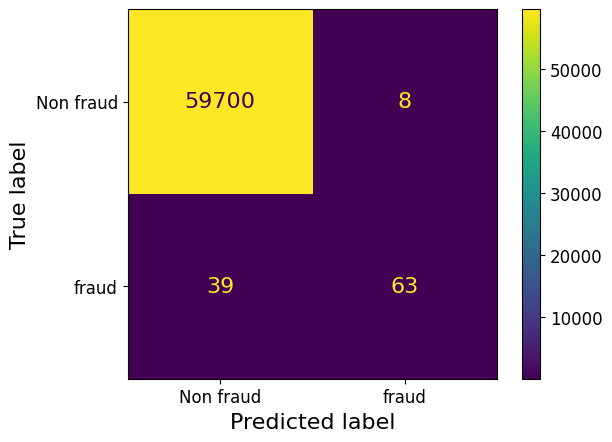

In [59]:
ConfusionMatrixDisplay.from_estimator(
    pipe_lr, X_valid, y_valid, display_labels=["Non fraud", "fraud"], values_format="d"
);

In [60]:
pipe_lr.named_steps["logisticregression"].classes_

array([0, 1])

Let's set "fraud" class a weight of 10.

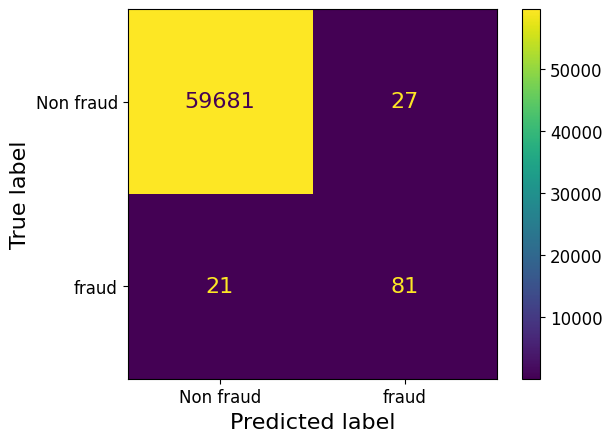

In [61]:
pipe_lr_weight = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=500, class_weight={0: 1, 1: 10})
)
pipe_lr_weight.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(
    pipe_lr_weight,
    X_valid,
    y_valid,
    display_labels=["Non fraud", "fraud"],
    values_format="d",
);

- Notice we've reduced false negatives and predicted more Fraud this time.
- This was equivalent to saying give 10x more "importance" to fraud class. 
- Note that as a consequence we are also increasing false positives.    

### `class_weight="balanced"`
- A useful setting is `class_weight="balanced"`.
- This sets the weights so that the classes are "equal".

> class_weight: dict, ‘balanced’ or None
If ‘balanced’, class weights will be given by n_samples / (n_classes * np.bincount(y)). If a dictionary is given, keys are classes and values are corresponding class weights. If None is given, the class weights will be uniform.

> sklearn.utils.class_weight.compute_class_weight(class_weight, classes, y)

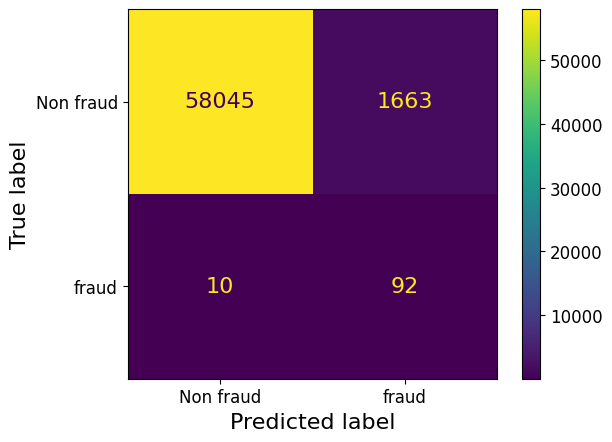

In [62]:
pipe_lr_balanced = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=500, class_weight="balanced")
)
pipe_lr_balanced.fit(X_train, y_train)
ConfusionMatrixDisplay.from_estimator(
    pipe_lr_balanced,
    X_valid,
    y_valid,
    display_labels=["Non fraud", "fraud"],
    values_format="d",
);

We have reduced false negatives but we have many more false positives now ...

### Are we doing better with `class_weight="balanced"`?

In [63]:
comp_dict = {}
pipe_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500))
scoring = ["accuracy", "f1", "recall", "precision", "roc_auc", "average_precision"]
orig_scores = cross_validate(pipe_lr, X_train_big, y_train_big, scoring=scoring)

In [64]:
pipe_lr_balanced = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=500, class_weight="balanced")
)
scoring = ["accuracy", "f1", "recall", "precision", "roc_auc", "average_precision"]
bal_scores = cross_validate(pipe_lr_balanced, X_train_big, y_train_big, scoring=scoring)
comp_dict = {
    "Original": pd.DataFrame(orig_scores).mean().tolist(),
    "class_weight='balanced'": pd.DataFrame(bal_scores).mean().tolist(),
}

In [65]:
pd.DataFrame(comp_dict, index=bal_scores.keys())

,Original,class_weight='balanced'
fit_time,0.079543,0.147826
score_time,0.017440,0.016318
test_accuracy,0.999192,0.973225
test_f1,0.716792,0.101894
test_recall,0.601712,0.891001
test_precision,0.888513,0.054054
test_roc_auc,0.967907,0.970518
test_average_precision,0.743135,0.730383


- Recall is much better but precision has dropped a lot; we have many false positives. 
- You could also optimize `class_weight` using hyperparameter optimization for your specific problem. 

- Changing the class weight will **generally reduce accuracy**.
- The original model was trying to maximize accuracy.
- Now you're telling it to do something different.
- But that can be fine, accuracy isn't the only metric that matters.

### Stratified Splits

- A similar idea of "balancing" classes can be applied to data splits.
- We have the same option in `train_test_split` with the `stratify` argument. 
- By default it splits the data so that if we have 10% negative examples in total, then each split will have 10% negative examples.

- If you are carrying out cross validation using `cross_validate`, by default it uses [`StratifiedKFold`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedKFold.html). From the documentation: 

> This cross-validation object is a variation of KFold that returns stratified folds. The folds are made by preserving the percentage of samples for each class.

- In other words, if we have 10% negative examples in total, then each fold will have 10% negative examples.

### Is stratifying a good idea? 

  - Well, it's no longer a random sample, which is probably theoretically bad, but not that big of a deal.
  - If you have many examples, it shouldn't matter as much.
  - It can be especially useful in multi-class, say if you have one class with very few cases.
  - In general, these are difficult questions.

```{note}
See [Appendix A (Lecture 09)](AppendixA.ipynb) for additional techniques to address class imbalance, including undersampling, oversampling, and SMOTE.  
```

<br><br><br><br>

## ML fairness activity

AI/ML systems can give the illusion of objectivity as they are derived from seemingly unbiased data & algorithm. However, human are inherently biased and AI/ML systems, if not carefully evaluated, can even further amplify the existing inequities and systemic bias in our society.  

How do we make sure our AI/ML systems are *fair*? Which metrics can we use to quantify 'fairness' in AI/ML systems?

Let's examine this on [the adult census data set](https://www.kaggle.com/uciml/adult-census-income). 

In [66]:
census_df = pd.read_csv(DATA_DIR + "adult.csv")
census_df.shape

(32561, 15)

In [67]:
train_df, test_df = train_test_split(census_df, test_size=0.4, random_state=42)

In [68]:
train_df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
25823,36,Private,245521,7th-8th,4,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,35,Mexico,<=50K
10274,26,Private,134287,Assoc-voc,11,Never-married,Sales,Own-child,White,Female,0,0,35,United-States,<=50K
27652,25,Local-gov,109526,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,38,United-States,<=50K
13941,23,Private,131275,HS-grad,9,Never-married,Craft-repair,Own-child,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
31384,27,Private,193122,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,25,Private,410240,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0,0,40,United-States,<=50K
5390,51,Private,146767,Assoc-voc,11,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K
860,55,Federal-gov,238192,HS-grad,9,Married-civ-spouse,Tech-support,Husband,White,Male,0,1887,40,United-States,>50K
15795,41,Private,154076,Some-college,10,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,50,United-States,>50K


In [69]:
train_df_nan = train_df.replace("?", np.nan)
test_df_nan = test_df.replace("?", np.nan)
train_df_nan.shape

(19536, 15)

In [70]:
# Let's identify numeric and categorical features

numeric_features = [
    "age",
    "capital.gain",
    "capital.loss",
    "hours.per.week",
]

categorical_features = [
    "workclass",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "native.country",
]

ordinal_features = ["education"]
binary_features = [
    "sex"
]  # Not binary in general but in this particular dataset it seems to have only two possible values
drop_features = ["education.num", "fnlwgt"]
target = "income"

In [71]:
train_df["education"].unique()

array(['7th-8th', 'Assoc-voc', 'HS-grad', 'Bachelors', 'Some-college',
       '10th', '11th', 'Prof-school', '12th', '5th-6th', 'Masters',
       'Assoc-acdm', '9th', 'Doctorate', '1st-4th', 'Preschool'],
      dtype=object)

In [72]:
education_levels = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Prof-school",
    "Assoc-voc",
    "Assoc-acdm",
    "Some-college",
    "Bachelors",
    "Masters",
    "Doctorate",
]

In [73]:
assert set(education_levels) == set(train_df["education"].unique())

In [74]:
X_train = train_df_nan.drop(columns=[target])
y_train = train_df_nan[target]

X_test = test_df_nan.drop(columns=[target])
y_test = test_df_nan[target]

In [75]:
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

numeric_transformer = make_pipeline(StandardScaler())

ordinal_transformer = OrdinalEncoder(categories=[education_levels], dtype=int)

categorical_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(handle_unknown="ignore", sparse_output=False),
)

binary_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    OneHotEncoder(drop="if_binary", dtype=int),
)

preprocessor = make_column_transformer(
    (numeric_transformer, numeric_features),
    (ordinal_transformer, ordinal_features),
    (binary_transformer, binary_features),
    (categorical_transformer, categorical_features),
    ("drop", drop_features),
)

In [76]:
y_train.value_counts()

income
<=50K    14841
>50K      4695
Name: count, dtype: int64

In [77]:
pipe_lr = make_pipeline(
    preprocessor, LogisticRegression(class_weight="balanced", max_iter=1000)
)

In [78]:
pipe_lr.fit(X_train, y_train);

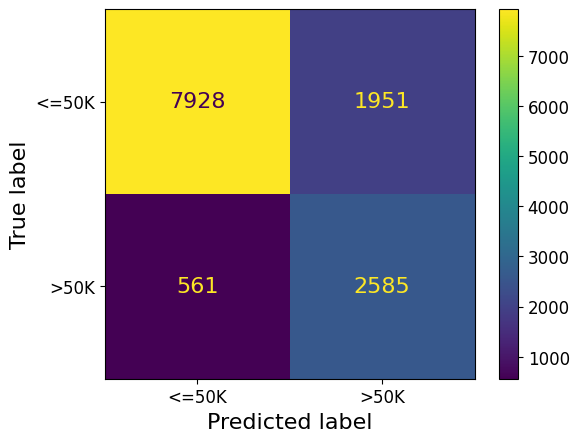

In [79]:
ConfusionMatrixDisplay.from_estimator(pipe_lr, X_test, y_test);

Let's examine confusion matrix separately for the two genders we have in the data. 

In [80]:
X_train_enc = preprocessor.fit_transform(X_train)
preprocessor.named_transformers_["pipeline-2"]["onehotencoder"].get_feature_names_out()

array(['x0_Male'], dtype=object)

In [81]:
X_test.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
14160,29,Private,280618,Some-college,10,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States
27048,19,Private,439779,Some-college,10,Never-married,Sales,Own-child,White,Male,0,0,15,United-States
28868,28,Private,204734,Some-college,10,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,40,United-States
5667,35,Private,107991,11th,7,Never-married,Sales,Not-in-family,White,Male,0,0,45,United-States
7827,20,Private,54152,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,NaN


In [82]:
X_female = X_test.query("sex=='Female'")  # X where sex is female
X_male = X_test.query("sex=='Male'")  # X where sex is male

y_female = y_test[X_female.index]  # y where sex is female
y_male = y_test[X_male.index]  # y where sex is male

**Get predictions for `X_female` and `y_male` with `pipe_lr`**

In [83]:
female_preds = pipe_lr.predict(X_female)
male_preds = pipe_lr.predict(X_male)

Let's examine the accuracy and confusion matrix for female and male classes.  

In [84]:
print(classification_report(y_female, female_preds))

              precision    recall  f1-score   support

       <=50K       0.96      0.94      0.95      3851
        >50K       0.57      0.66      0.61       463

    accuracy                           0.91      4314
   macro avg       0.76      0.80      0.78      4314
weighted avg       0.92      0.91      0.91      4314



In [85]:
print(classification_report(y_male, male_preds))

              precision    recall  f1-score   support

       <=50K       0.91      0.72      0.80      6028
        >50K       0.57      0.85      0.68      2683

    accuracy                           0.76      8711
   macro avg       0.74      0.78      0.74      8711
weighted avg       0.81      0.76      0.77      8711



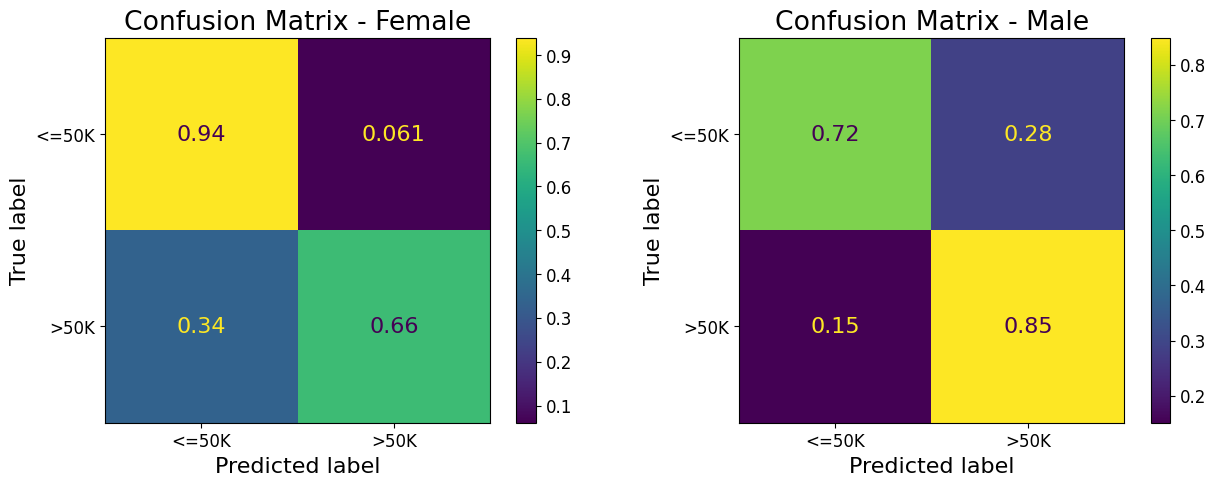

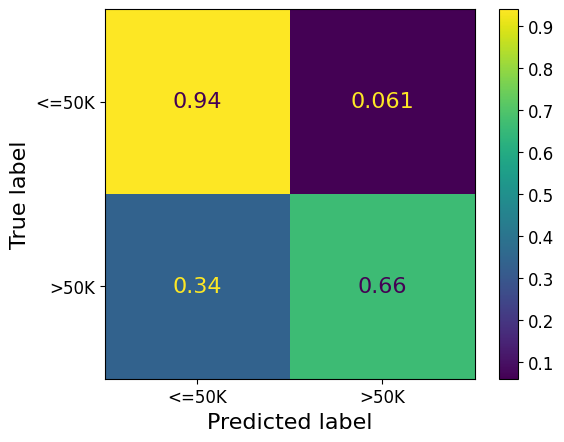

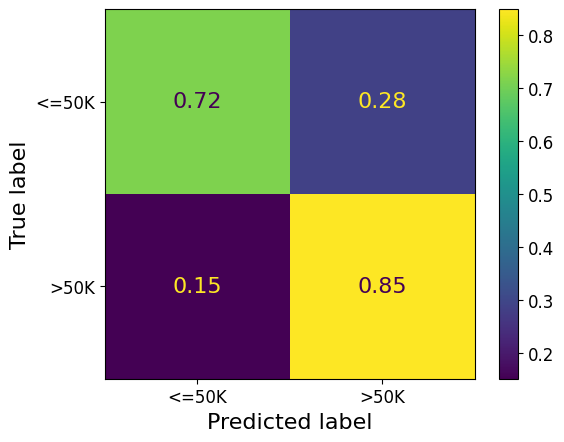

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot the female confusion matrix
female_cm = ConfusionMatrixDisplay.from_estimator(pipe_lr, X_female, y_female, normalize="true");
axes[0].set_title('Confusion Matrix - Female');
female_cm.plot(ax=axes[0]);


# Plot the male confusion matrix
male_cm = ConfusionMatrixDisplay.from_estimator(pipe_lr, X_male, y_male, normalize="true");
axes[1].set_title('Confusion Matrix - Male');
male_cm.plot(ax=axes[1]);

### ❓❓ Questions for group discussion

Let's assume that a company is using this classifier for loan approval with a simple rule that if the income is >=50K, approve the loan else reject the loan. 

In your group, discuss the questions below. 

1. Which group has a higher accuracy?
2. Which group has a higher precision for class >50K? What about recall for class >50K?
3. Will both groups have more or less the same proportion of people with approved loans? 
4. If a male and a female have both a certain level of income, will they have the same chance of getting the loan?
5. Banks want to avoid approving unqualified applications (false positives) because default loan could have detrimental effects for them. Compare the false positive rates for the two groups.    
6. Overall, do you think this income classifier will fairly treat both groups? What will be the consequences of using this classifier in loan approval application? 


**Time permitting**
1. Do you think the effect will still exist if the sex feature is removed from the model (but you still have it available separately to do the two confusion matrices)? 
2. Are there any other groups in this dataset worth examining for biases? 

<br><br>

## What did we learn today? 

- A number of possible ways to evaluate machine learning models 
    - Choose the evaluation metric that makes most sense in your context or which is most common in your discipline  
- Two kinds of binary classification problems 
    - Distinguishing between two classes (e.g., dogs vs. cats)
    - Spotting a class (e.g., spot fraud transaction, spot spam)

- Precision, recall, f1-score are useful when dealing with spotting problems. 
- The thing that we are interested in spotting is considered "positive".   
- Do you need to deal with class imbalance in the given problem? 
- Methods to deal with class imbalance 
    - Changing the training procedure 
        - `class_weight`
    - Changing the data
        - undersampling, oversampling, SMOTE
        

- Do not blindly make decisions solely based on ML model predictions. 
- Try to carefully analyze the errors made by the model on certain groups.  

### Relevant papers and resources 

- [The Relationship Between Precision-Recall and ROC Curves](https://www.biostat.wisc.edu/~page/rocpr.pdf)
- [Article claiming that PR curve are better than ROC for imbalanced datasets](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432)
- [Precision-Recall-Gain Curves: PR Analysis Done Right](https://papers.nips.cc/paper/2015/file/33e8075e9970de0cfea955afd4644bb2-Paper.pdf)
- [ROC animation](https://github.com/dariyasydykova/open_projects/tree/master/ROC_animation)
- [Generalization in Adaptive Data Analysis and Holdout Reuse](https://arxiv.org/pdf/1506.02629.pdf)